# NSW Active-Fire Reliability Pilot - Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the active-fire hotspots dataset and NPWS fire history boundaries to understand spatial distributions, temporal offsets, and sensor-specific characteristics.

In [1]:
# Execution Configuration
EXECUTION_MODE = "snapshot"  # Options: "snapshot"
SNAPSHOT_SLUG = "tuannm3812/nsw-active-fire-pilot-snapshot"

import json
import os
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [2]:
# Locate and load the snapshot dataset
dataset_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'dea_hotspots.geojson' in files:
        dataset_dir = Path(root)
        print(f"Found dataset at: {dataset_dir}")
        break
if dataset_dir is None:
    for root, dirs, files in os.walk('../input'):
        if 'dea_hotspots.geojson' in files:
            dataset_dir = Path(root)
            print(f"Found dataset at: {dataset_dir}")
            break
if dataset_dir is None:
    dataset_dir = Path('.')
    print(f"Dataset not found in Kaggle inputs. Falling back to local: {dataset_dir}")

dea_path = dataset_dir / 'dea_hotspots.geojson'
npws_path = dataset_dir / 'npws_fire_history.geojson'

print('Loading spatial datasets...')
with open(dea_path) as f:
    dea_data = json.load(f)
with open(npws_path) as f:
    npws_data = json.load(f)

print(f"Loaded {len(dea_data['features']):,} hotspots and {len(npws_data['features']):,} fire polygons.")

Dataset not found in Kaggle inputs. Falling back to local: .
Loading spatial datasets...
Loaded 19,849 hotspots and 14 fire polygons.


In [3]:
# Normalize datasets into pandas DataFrames
hotspots_list = []
for feature in dea_data['features']:
    props = feature.get('properties', {})
    geom = feature.get('geometry', {})
    coords = geom.get('coordinates', [np.nan, np.nan])
    hotspots_list.append({
        'id': props.get('id'),
        'datetime': pd.to_datetime(props.get('datetime')),
        'longitude': props.get('longitude', coords[0]),
        'latitude': props.get('latitude', coords[1]),
        'sensor': props.get('sensor'),
        'satellite': props.get('satellite'),
        'temp_kelvin': props.get('temp_kelvin'),
        'power': props.get('power'),
        'confidence': props.get('confidence'),
        'accuracy': props.get('accuracy'),
    })
df_hotspots = pd.DataFrame(hotspots_list)

fires_list = []
for feature in npws_data['features']:
    props = feature.get('properties', {})
    fires_list.append({
        'fire_id': props.get('FireNo') or str(props.get('OBJECTID')),
        'fire_name': props.get('FireName') or 'Unnamed',
        'ignition_date': pd.to_datetime(props.get('StartDate')),
        'extinguish_date': pd.to_datetime(props.get('EndDate')),
        'area_ha': props.get('AreaHa'),
        'perimeter_m': props.get('PerimeterM')
    })
df_fires = pd.DataFrame(fires_list)

print('Hotspots head:')
display(df_hotspots.head())
print('\nFires head:')
display(df_fires.head())

Hotspots head:


,id,datetime,longitude,latitude,sensor,satellite,temp_kelvin,power,confidence,accuracy
0,31744283,2020-01-07 03:04:31+00:00,150.9424,-32.6579,VIIRS,SUOMI NPP,313.22,15.6,56,± 0.375km
1,31744525,2020-01-07 03:30:00+00:00,150.3066,-32.4396,AHI,HIMAWARI-8,803.80,32.0,50,± 2km
2,31744716,2020-01-07 03:40:00+00:00,150.3066,-32.4396,AHI,HIMAWARI-8,427.60,46.3,50,± 2km
3,31744928,2020-01-07 03:50:00+00:00,149.6190,-32.6631,AHI,HIMAWARI-8,608.30,53.1,50,± 2km
4,31745332,2020-01-07 04:10:00+00:00,150.6484,-32.4933,AHI,HIMAWARI-8,423.80,54.2,50,± 2km



Fires head:


,fire_id,fire_name,ignition_date,extinguish_date,area_ha,perimeter_m
0,20011071581,Eskdale Rd,1970-01-01 00:26:18.574800,1970-01-01 00:26:19.006800,7.532281,None
1,19122065204,Grose Valley,1970-01-01 00:26:16.800000,1970-01-01 00:26:20.774400,19895.552675,None
2,19120461695,"Upper Turon Rd, Palmers Oaky",1970-01-01 00:26:15.378000,1970-01-01 00:26:20.389200,17373.433451,None
3,20011071682,Spring Gully,1970-01-01 00:26:18.574800,1970-01-01 00:26:20.907600,109.068812,None
4,20012273243,Woodlands,1970-01-01 00:26:18.574800,1970-01-01 00:26:20.821200,203.194782,None


## 1. Spatial Distribution Analysis

Let us visualize the spatial distribution of hotspots colored by sensor, overlaying the fire boundary polygons.

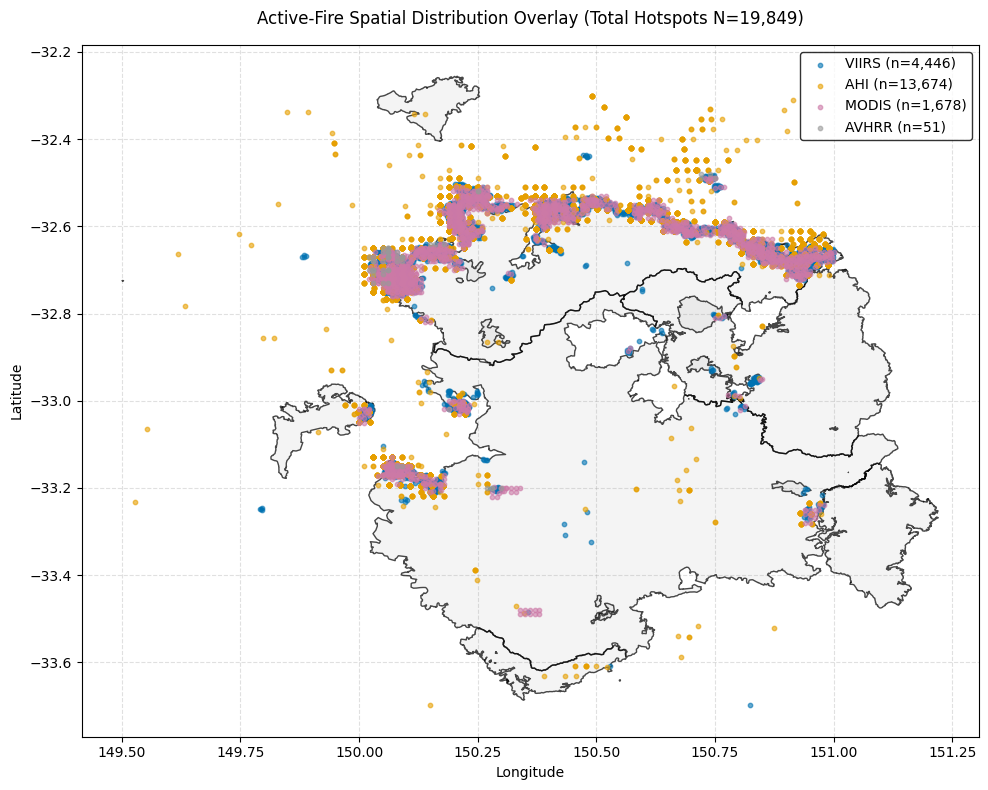

In [4]:
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

OKABE_ITO_COLORS = ['#0072B2', '#E69F00', '#CC79A7', '#999999']
sensors = df_hotspots['sensor'].unique()

# 1. Plot boundary outlines
for feature in npws_data['features']:
    geom = feature.get('geometry', {})
    coords = geom.get('coordinates', [])
    poly_list = [coords] if geom.get('type') == 'Polygon' else coords
    for poly in poly_list:
        for ring in poly:
            x = [pt[0] for pt in ring]
            y = [pt[1] for pt in ring]
            ax.plot(x, y, color='black', linewidth=1.0, alpha=0.7, zorder=2)
            ax.fill(x, y, color='#999999', alpha=0.1, zorder=1)

# 2. Scatter plot hotspots per sensor
for idx, sensor in enumerate(sensors):
    subset = df_hotspots[df_hotspots['sensor'] == sensor]
    ax.scatter(subset['longitude'], subset['latitude'], 
               color=OKABE_ITO_COLORS[idx % len(OKABE_ITO_COLORS)], 
               label=f"{sensor} (n={len(subset):,})", s=10, alpha=0.6, zorder=3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f"Active-Fire Spatial Distribution Overlay (Total Hotspots N={len(df_hotspots):,})", fontsize=12, pad=15)
ax.legend(facecolor='white', edgecolor='black')
ax.grid(True, linestyle='--', alpha=0.3, color='#999999')
plt.tight_layout()
plt.show()

## 2. Sensor Attribute Relationships

Let us explore the relationship between fire radiative power (FRP / power), temperature (Kelvin), and confidence scores across different sensors.

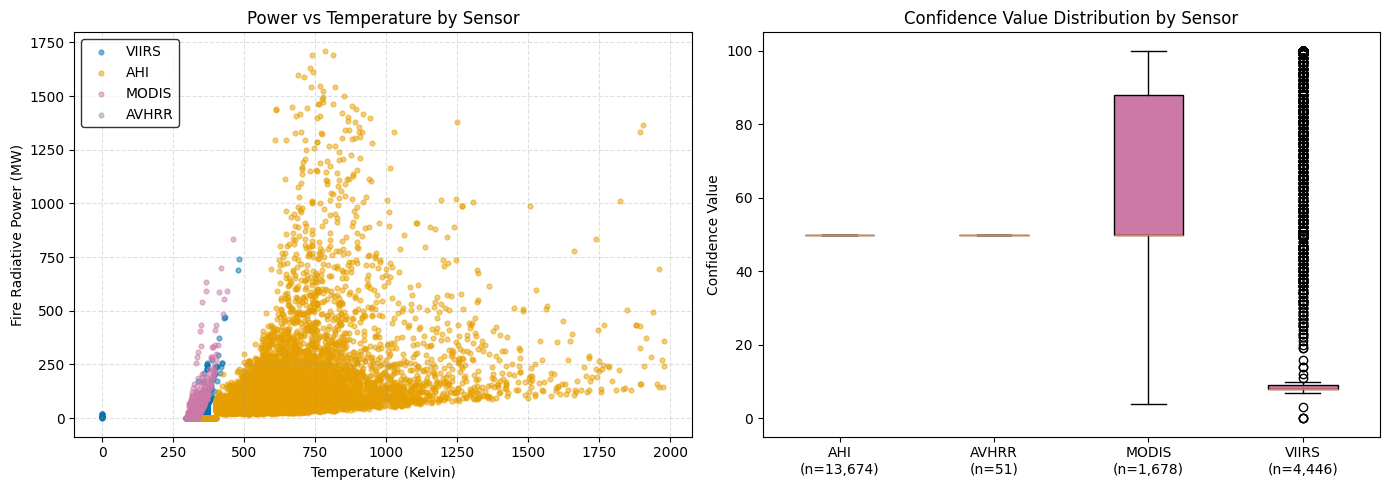

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
for ax in axes:
    ax.set_facecolor('white')

# Left: Scatter plot power vs temperature
for idx, sensor in enumerate(sensors):
    subset = df_hotspots[df_hotspots['sensor'] == sensor]
    axes[0].scatter(subset['temp_kelvin'], subset['power'], 
                    color=OKABE_ITO_COLORS[idx % len(OKABE_ITO_COLORS)], 
                    label=sensor, s=12, alpha=0.5)
axes[0].set_xlabel('Temperature (Kelvin)')
axes[0].set_ylabel('Fire Radiative Power (MW)')
axes[0].set_title('Power vs Temperature by Sensor')
axes[0].legend(facecolor='white', edgecolor='black')
axes[0].grid(True, linestyle='--', alpha=0.3, color='#999999')

# Right: Boxplot of confidence values per sensor
box_data = []
box_labels = []
for sensor in sorted(sensors):
    subset = df_hotspots[df_hotspots['sensor'] == sensor]['confidence'].dropna()
    if not subset.empty:
        box_data.append(subset.values)
        box_labels.append(f"{sensor}\n(n={len(subset):,})")

# Check Matplotlib version for boxplot argument compatibility
import re
import matplotlib
try:
    v_parts = [int(x) for x in re.findall(r'\d+', matplotlib.__version__)]
except Exception:
    v_parts = [3, 0]
use_tick_labels = len(v_parts) >= 2 and (v_parts[0] > 3 or (v_parts[0] == 3 and v_parts[1] >= 9))

if use_tick_labels:
    box = axes[1].boxplot(box_data, tick_labels=box_labels, patch_artist=True)
else:
    box = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)

for patch in box['boxes']:
    patch.set_facecolor('#CC79A7')
    patch.set_edgecolor('black')

axes[1].set_ylabel('Confidence Value')
axes[1].set_title('Confidence Value Distribution by Sensor')
plt.tight_layout()
plt.show()

In [6]:
# Verify basic dataset invariants match expected snapshot sizes
assert len(df_hotspots) == 19849, f"Expected 19,849 hotspots, got {len(df_hotspots):,}"
assert len(df_fires) == 14, f"Expected 14 fire boundary features, got {len(df_fires):,}"
print('[PASS] Basic EDA invariants verified successfully.')

[PASS] Basic EDA invariants verified successfully.
